In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Stock Data Pre-Processing

## 1. Equity Data Reshaping

This section cleans and reshapes a stock dataset exported from Bloomberg (Excel format with multi-level columns).

---

### Key Steps

- Fill down missing ticker names in the column headers  
- Extract the date column and set it as the index  
- Reshape the data from wide to long format with columns: `date`, `ticker`, `feature`  
- Keep only the selected financial features needed for modeling  

In [2]:
# 1. Read the CSV with multi-level headers
df = pd.read_csv('equity.csv', header=[0, 1])

# 2. Set column index names
df.columns.names = ['ticker_raw', 'field']

# 3. Extract raw ticker and field names
raw_tickers = df.columns.get_level_values('ticker_raw')
fields = df.columns.get_level_values('field')

# 4. Forward fill the ticker names
tickers = []
last = None
for tk in raw_tickers:
    if not tk.startswith('Unnamed'):
        last = tk
    tickers.append(last)

# 5. Rebuild proper MultiIndex from filled tickers and their corresponding field names
mi = pd.MultiIndex.from_tuples(zip(tickers, fields), names=['ticker', 'field'])
df.columns = mi

# 6. Extract the 'Dates' column and set it as datetime index
date_col = [c for c in df.columns if c[1] == 'Dates'][0]
df.index = pd.to_datetime(df[date_col])
df.index.name = 'date'
df = df.drop(columns=[date_col])  # Drop the original 'Dates' column

# 7. Stack the 'ticker' level to convert from wide to long format
df_long = df.stack(level='ticker').reset_index()

# 8. Select and reorder only the fields of interest
fields_wanted = [
    'PX_HIGH','PX_LOW','PX_OPEN','PX_LAST',
    'PX_VOLUME','PE_RATIO','PX_TO_BOOK_RATIO','PX_TO_SALES_RATIO',
    'EQY_DVD_YLD_12M','DAY_TO_DAY_TOT_RETURN_GROSS_DVDS',
    'CUR_MKT_CAP', 'IVOL_DELTA',
    'CALL_IMP_VOL_30D','IVOL_IMPLIED_FORWARD'
]

# Ensure selected columns exist before selecting
available_fields = [f for f in fields_wanted if f in df_long.columns]
df_long = df_long[['date', 'ticker'] + available_fields]

# 9. Export to CSV in long format
df_long.to_csv('equity_long_format.csv', index=False)

# 10. Preview the result
print(df_long.head())

/var/folders/bh/8vlm7qp54dnf4_wrqpc5trsm0000gn/T/ipykernel_29626/3417262770.py:30: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df_long = df.stack(level='ticker').reset_index()


field       date          ticker  PX_HIGH   PX_LOW  PX_OPEN  PX_LAST  \
0     2008-01-02     A UN Equity  26.3081  25.8289  26.2365  25.9577   
1     2008-01-02  AAPL UW Equity   7.1500   6.8768   7.1246   6.9586   
2     2008-01-02  ABBV UN Equity  37.0000  34.9100  37.0000  35.0000   
3     2008-01-02  ABNB UW Equity      NaN      NaN      NaN      NaN   
4     2008-01-02   ABT UN Equity  27.1007  26.5600  26.8088  26.7036   

field    PX_VOLUME  PE_RATIO  PX_TO_BOOK_RATIO  PX_TO_SALES_RATIO  \
0         932000.0   16.5978            2.9698             1.8827   
1      495903436.0   42.9163           10.1876             6.2653   
2         345652.0    9.9106            3.5590             3.0587   
3              NaN       NaN               NaN                NaN   
4        2338500.0    9.7320            2.3280             1.5948   

field  EQY_DVD_YLD_12M  DAY_TO_DAY_TOT_RETURN_GROSS_DVDS  CUR_MKT_CAP  \
0                  NaN                           -1.1976   13431.0000   
1     

## 2. Dropping `EQY_DVD_YLD_12M` Due to Excessive Missing Values

The feature `EQY_DVD_YLD_12M` has too many missing values and will be removed from the dataset.

---

### Steps Taken

1. Grouped data by `ticker` and checked if the column is fully missing (`NaN`) for each ticker  
2. Counted how many tickers are affected  
3. Dropped the column `EQY_DVD_YLD_12M` from the cleaned dataset

In [3]:
# Read the cleaned long-format equity data
pre_df = pd.read_csv('equity_long_format.csv')

# 1. For each ticker, check if EQY_DVD_YLD_12M is completely missing (all values are NaN)
all_missing = pre_df.groupby('ticker')['EQY_DVD_YLD_12M'] \
                .apply(lambda x: x.isna().all())

# 2. Count how many tickers have EQY_DVD_YLD_12M completely missing
num_missing_tickers = all_missing.sum()

# Print the result
print(f"Number of tickers with completely missing EQY_DVD_YLD_12M: {num_missing_tickers}")

Number of tickers with completely missing EQY_DVD_YLD_12M: 82


In [4]:
# Since the column 'EQY_DVD_YLD_12M' contains too many missing values, dropping it entirely
pre_df.drop(columns=['EQY_DVD_YLD_12M'], inplace=True)

## 3. Data Cleaning and Missing Value Check

This section runs final checks and cleaning steps on the equity dataset.

---

### Steps

1. **Convert `date` to datetime format**  
   Enables proper sorting, filtering, and time-based analysis.

2. **Filter date range to 2010–2020**  
   Focus on a clean and consistent historical window.

3. **Drop tickers with missing `PX_LAST` values**  
   Remove any stock that has missing prices in this period, since `PX_LAST` is required for return and signal calculations.

4. **Check missing values after filtering**  
   - Count missing entries per column  
   - Compute percentage of missing values  
   - Combine into a summary table for review and export

In [5]:
# 1. Ensure the 'date' column is in datetime format
pre_df['date'] = pd.to_datetime(pre_df['date'])

# 2. Define the start and end dates for filtering
start_date = '2010-01-01'
end_date   = '2020-12-31'

# 3. Filter the DataFrame to include only rows within the specified date range
pre_df = pre_df[(pre_df['date'] >= start_date) & (pre_df['date'] <= end_date)]


In [6]:
# Calculate the number of missing values in each column
missing_count = pre_df.isna().sum()

# Calculate the percentage of missing values per column
missing_percent = (missing_count / len(pre_df)) * 100

# Combine into a summary DataFrame
missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percent (%)': missing_percent.round(2)
})

# Display the summary of missing values
print(missing_summary)

                                  Missing Count  Missing Percent (%)
date                                          0                 0.00
ticker                                        0                 0.00
PX_HIGH                                   82014                 6.21
PX_LOW                                    82014                 6.21
PX_OPEN                                   82014                 6.21
PX_LAST                                   82014                 6.21
PX_VOLUME                                 82005                 6.21
PE_RATIO                                 146290                11.07
PX_TO_BOOK_RATIO                         131396                 9.94
PX_TO_SALES_RATIO                         91893                 6.95
DAY_TO_DAY_TOT_RETURN_GROSS_DVDS          82044                 6.21
CUR_MKT_CAP                               67622                 5.12
IVOL_DELTA                                83265                 6.30
CALL_IMP_VOL_30D                  

In [7]:
# Ensure the 'date' column is in datetime format
pre_df['date'] = pd.to_datetime(pre_df['date'])

# 1. Filter the date range from 2010-01-01 to 2020-12-31
mask = (pre_df['date'] >= '2010-01-01') & (pre_df['date'] <= '2020-12-31')
df_period = pre_df[mask]

# 2. Identify tickers that have missing values in 'PX_LAST' during this period
tickers_with_nan = df_period[df_period['PX_LAST'].isna()]['ticker'].unique()

# 3. Remove all data for those tickers from the full dataset
pre_df = pre_df[~pre_df['ticker'].isin(tickers_with_nan)]


In [8]:
# Count the number of missing (NaN) values in each column
missing_count = pre_df.isna().sum()

# Calculate the percentage of missing values per column
missing_percent = (missing_count / len(pre_df)) * 100

# Combine both into a summary DataFrame
missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percent (%)': missing_percent.round(2)
})

print(missing_summary)


                                  Missing Count  Missing Percent (%)
date                                          0                 0.00
ticker                                        0                 0.00
PX_HIGH                                       0                 0.00
PX_LOW                                        0                 0.00
PX_OPEN                                       0                 0.00
PX_LAST                                       0                 0.00
PX_VOLUME                                     1                 0.00
PE_RATIO                                  53749                 4.55
PX_TO_BOOK_RATIO                          45852                 3.88
PX_TO_SALES_RATIO                          8174                 0.69
DAY_TO_DAY_TOT_RETURN_GROSS_DVDS              0                 0.00
CUR_MKT_CAP                                   5                 0.00
IVOL_DELTA                                69183                 5.85
CALL_IMP_VOL_30D                  

## 4. Ticker Filtering and Missing Value Cleaning

This section ensures only reliable tickers with good data quality are kept.

---

### Steps

1. **Filter by valid tickers from news data**  
   Keep only the tickers that appear in the external news dataset.

2. **Check missing values by column**  
   - Count missing values for each feature  
   - Calculate missing percentage

3. **Check missing values by ticker**  
   For each ticker, calculate how much data is missing across all columns.

4. **Drop tickers with high missing rates**  
   Remove any ticker that has more than 20% missing in any feature column.

5. **Plot heatmap of missing data**  
   Show missing value percentages by ticker and feature after cleaning.

---


In [9]:
# 1. Define tickers to keep (from news data)
keep_tickers = [
    'GILD', 'QQQ', 'WFC', 'MRK', 'KO', 'MS', 'QCOM', 'CMCSA', 'FDX', 'GE',
    'GLD', 'GME', 'ORCL', 'AMT', 'OXY', 'CAT', 'SLB', 'EBAY', 'NKE', 'PEP',
    'EA', 'TXN', 'DISH', 'V', 'COP', 'WDC', 'KSS', 'COST', 'NEE', 'XLF',
    'BHP', 'BIDU', 'PBR', 'BIIB', 'TSM', 'TJX', 'AEO', 'XLE', 'CSX', 'CI',
    'BX', 'TSN', 'DUK', 'MMM', 'NVS', 'GRPN', 'NOK', 'XLK', 'TM', 'D',
    'ALK', 'GSK', 'HUM', 'USO', 'FSLR', 'TRV', 'AMGN', 'BSX', 'AIG',
    'SPWR', 'EOG', 'SIRI', 'XLU', 'DHR', 'DHI', 'USB', 'XLY', 'DFS',
    'NSC', 'NEM', 'KMB', 'HPQ', 'NOC', 'BAX', 'COF', 'XLP', 'DB', 'CLX',
    'CME', 'ACN', 'KKR', 'NDAQ', 'RL', 'WEN', 'TAP', 'PRU', 'ICE', 'UPS',
    'AMTD', 'GDX', 'PM', 'XRT'
]

# 2. Replace Bloomberg ticker with simplified ticker
pre_df['ticker'] = pre_df['ticker'].str.split().str[0]

# 3. Filter rows based on ticker
pre_df = pre_df[pre_df['ticker'].isin(keep_tickers)].copy()

# 4. Display stats
print(f"Number of rows after filtering: {len(pre_df)}")
print(f"Number of unique tickers retained: {pre_df['ticker'].nunique()}")
print(f"Unique tickers: {sorted(pre_df['ticker'].unique().tolist())}")

Number of rows after filtering: 149526
Number of unique tickers retained: 54
Unique tickers: ['ACN', 'AIG', 'AMGN', 'AMT', 'BAX', 'BSX', 'BX', 'CAT', 'CI', 'CLX', 'CMCSA', 'CME', 'COF', 'COP', 'COST', 'D', 'DHI', 'DHR', 'DUK', 'EA', 'EBAY', 'EOG', 'FDX', 'FSLR', 'GE', 'GILD', 'HPQ', 'HUM', 'ICE', 'KKR', 'KO', 'MMM', 'MRK', 'MS', 'NDAQ', 'NEE', 'NEM', 'NKE', 'NOC', 'NSC', 'OXY', 'PM', 'PRU', 'QCOM', 'RL', 'SLB', 'TAP', 'TJX', 'TRV', 'TSN', 'UPS', 'USB', 'V', 'WFC']


In [10]:
# Count the number of missing (NaN) values in each column
missing_count = pre_df.isna().sum()

# Calculate the percentage of missing values per column
missing_percent = (missing_count / len(pre_df)) * 100

# Combine both into a summary DataFrame
missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percent (%)': missing_percent.round(2)
})

print(missing_summary)

                                  Missing Count  Missing Percent (%)
date                                          0                 0.00
ticker                                        0                 0.00
PX_HIGH                                       0                 0.00
PX_LOW                                        0                 0.00
PX_OPEN                                       0                 0.00
PX_LAST                                       0                 0.00
PX_VOLUME                                     0                 0.00
PE_RATIO                                   3785                 2.53
PX_TO_BOOK_RATIO                           4063                 2.72
PX_TO_SALES_RATIO                           251                 0.17
DAY_TO_DAY_TOT_RETURN_GROSS_DVDS              0                 0.00
CUR_MKT_CAP                                   1                 0.00
IVOL_DELTA                                 3711                 2.48
CALL_IMP_VOL_30D                  

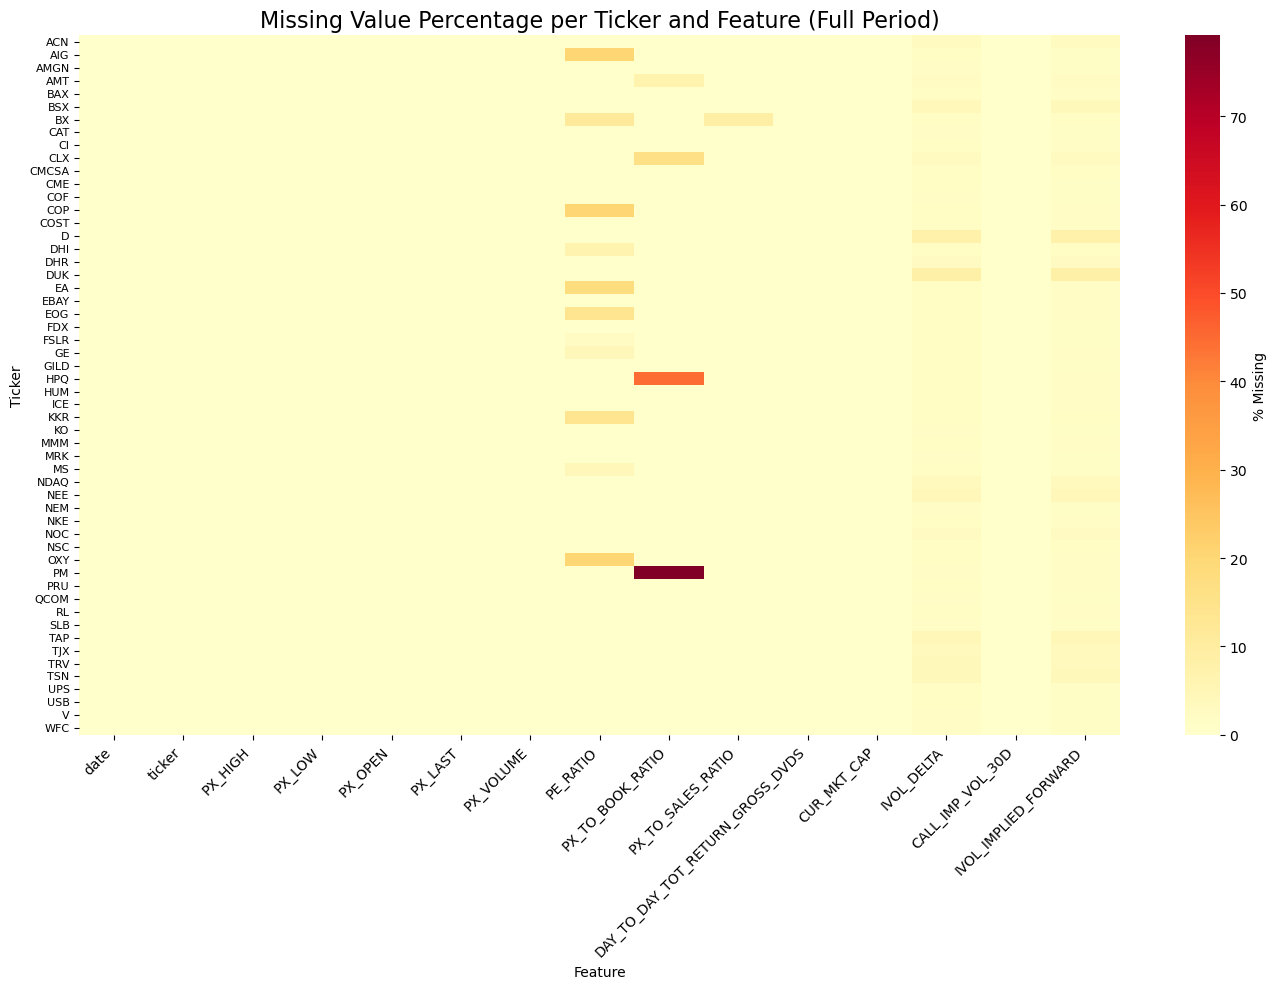

In [11]:
# Get unique list of tickers
filtered_ticker = pre_df['ticker'].dropna().unique()

# Calculate the percentage of missing values for each column within each ticker
nan_ratio_dict = {}
for ticker in filtered_ticker:
    sub_df = pre_df[pre_df['ticker'] == ticker]
    nan_ratio = sub_df.isna().sum() / len(sub_df) * 100
    nan_ratio_dict[ticker] = nan_ratio

# Build a DataFrame where rows are tickers and columns are features
nan_ratio_df = pd.DataFrame(nan_ratio_dict).T
nan_ratio_df.index.name = 'ticker'

# Plot a heatmap of missing value percentages
plt.figure(figsize=(14, 10))
sns.heatmap(
    nan_ratio_df,
    annot=False,
    fmt=".1f",
    cmap="YlOrRd",
    cbar_kws={'label': '% Missing'}
)
plt.title('Missing Value Percentage per Ticker and Feature (Full Period)', fontsize=16)
plt.ylabel('Ticker')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

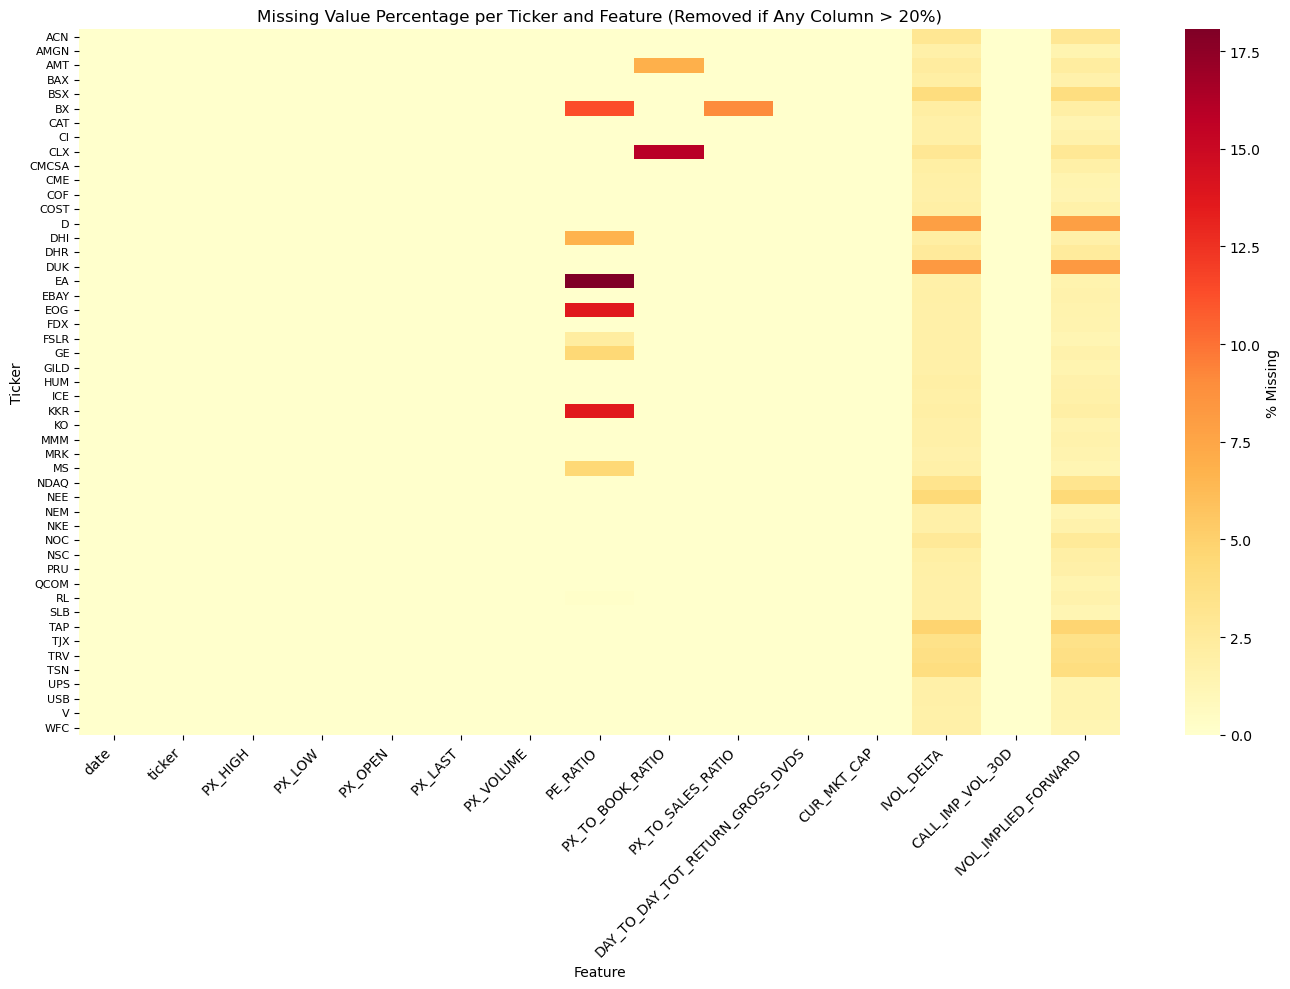

Number of tickers remaining after cleaning: 49


In [12]:
# Identify tickers with any feature having more than 20% missing values
tickers_to_drop = nan_ratio_df[nan_ratio_df.max(axis=1) > 20].index

# Remove all data for those tickers from the original dataset
cleaned_df = pre_df[~pre_df['ticker'].isin(tickers_to_drop)]

# Recalculate missing value percentages for the cleaned dataset
filtered_ticker = cleaned_df['ticker'].dropna().unique()
nan_ratio_dict_cleaned = {}

for ticker in filtered_ticker:
    sub_df = cleaned_df[cleaned_df['ticker'] == ticker]
    nan_ratio = sub_df.isna().sum() / len(sub_df) * 100
    nan_ratio_dict_cleaned[ticker] = nan_ratio

# Convert the cleaned missing ratio dictionary to a DataFrame
nan_ratio_df_cleaned = pd.DataFrame(nan_ratio_dict_cleaned).T
nan_ratio_df_cleaned.index.name = 'ticker'

# Plot heatmap of missing value percentages after filtering
plt.figure(figsize=(14, 10))
sns.heatmap(
    nan_ratio_df_cleaned,
    annot=False,
    fmt=".1f",
    cmap="YlOrRd",
    cbar_kws={'label': '% Missing'}
)
plt.title('Missing Value Percentage per Ticker and Feature (Removed if Any Column > 20%)')
plt.ylabel('Ticker')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# Display number of tickers remaining after cleaning
remaining_ticker_count = cleaned_df['ticker'].nunique()
print(f"Number of tickers remaining after cleaning: {remaining_ticker_count}")

## 5. Handling Missing Values with Rolling Mean and Fallback Strategy

To prepare data for modeling, missing values in selected numeric features are filled using a two-step method.

---

### Step 1: Rolling Mean (Window = 5)

- For each ticker, sort data by date (oldest to newest)  
- Fill missing values using the **mean of the past 5 valid values**, excluding the current row  
- This uses only **past data**, so it avoids any lookahead bias

---

### Step 2: Fallback — Forward Fill

- If the rolling window has no valid values (e.g. early rows), use the **last known valid value**  
- This forward-fill is applied within each ticker, still preserving causality

---

In [13]:
# Initialize a list to hold tickers whose first row contains any missing values
tickers_with_nan_in_first = []

# Iterate through each unique ticker
for ticker in cleaned_df['ticker'].dropna().unique():
    sub_df = cleaned_df[cleaned_df['ticker'] == ticker]
    first = sub_df.head(1)  # Extract the first row
    if first.isna().any().any():  # Check if any value in that row is NaN
        tickers_with_nan_in_first.append(ticker)

# Remove all data for those tickers from the cleaned DataFrame
final_df = cleaned_df[~cleaned_df['ticker'].isin(tickers_with_nan_in_first)]

# Output the number and list of tickers removed
print(f"Number of tickers with missing values in the first row: {len(tickers_with_nan_in_first)}")
print("Affected tickers:")
print(tickers_with_nan_in_first)

Number of tickers with missing values in the first row: 3
Affected tickers:
['BX', 'DHI', 'EA']


In [14]:
# Count missing values in each column
missing_count = final_df.isna().sum()

# Calculate percentage of missing values in each column
missing_percent = (missing_count / len(final_df)) * 100

# Combine into a summary DataFrame
missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percent (%)': missing_percent.round(2)
})

# Display the summary
print("\nMissing value summary per column:")
print(missing_summary)


Missing value summary per column:
                                  Missing Count  Missing Percent (%)
date                                          0                 0.00
ticker                                        0                 0.00
PX_HIGH                                       0                 0.00
PX_LOW                                        0                 0.00
PX_OPEN                                       0                 0.00
PX_LAST                                       0                 0.00
PX_VOLUME                                     0                 0.00
PE_RATIO                                   1077                 0.85
PX_TO_BOOK_RATIO                            630                 0.49
PX_TO_SALES_RATIO                             0                 0.00
DAY_TO_DAY_TOT_RETURN_GROSS_DVDS              0                 0.00
CUR_MKT_CAP                                   1                 0.00
IVOL_DELTA                                 3280                 2.58

In [15]:
# Columns to fill using rolling mean or last valid value
columns_to_fill = [
    'PE_RATIO',
    'PX_TO_BOOK_RATIO',
    'PX_TO_SALES_RATIO',
    'CUR_MKT_CAP',
    'IVOL_DELTA',
    'CALL_IMP_VOL_30D'
]

# Sort the dataset by ticker and date
final_df = final_df.sort_values(['ticker', 'date'])

# Custom function: fill NaNs with rolling mean, fallback to last valid value
def fill_rolling_then_last(group, cols, window=5):
    for col in cols:
        past_mean = (
            group[col]
            .shift()
            .rolling(window=window, min_periods=1)
            .apply(lambda x: x.dropna().mean(), raw=False)
        )
        filled = group[col].fillna(past_mean)
        filled = filled.fillna(method='ffill')
        group[col] = filled
    return group

# Apply per ticker for most columns
final_df_filled = (
    final_df
    .groupby('ticker', group_keys=False)
    .apply(lambda g: fill_rolling_then_last(g, columns_to_fill))
    .reset_index(drop=True)
)

# Fill IVOL_IMPLIED_FORWARD: if NaN, use PX_LAST
final_df_filled['IVOL_IMPLIED_FORWARD'] = final_df_filled['IVOL_IMPLIED_FORWARD'].fillna(final_df_filled['PX_LAST'])


/var/folders/bh/8vlm7qp54dnf4_wrqpc5trsm0000gn/T/ipykernel_29626/3855426431.py:24: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  filled = filled.fillna(method='ffill')
/var/folders/bh/8vlm7qp54dnf4_wrqpc5trsm0000gn/T/ipykernel_29626/3855426431.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: fill_rolling_then_last(g, columns_to_fill))


In [16]:
# Count missing values for each column
missing_count = final_df_filled.isna().sum()

# Calculate missing percentage per column
missing_percent = (missing_count / len(final_df_filled)) * 100

# Combine results into a summary DataFrame
missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percent (%)': missing_percent.round(2)
})

# Display the missing value summary
print(missing_summary)

                                  Missing Count  Missing Percent (%)
date                                          0                  0.0
ticker                                        0                  0.0
PX_HIGH                                       0                  0.0
PX_LOW                                        0                  0.0
PX_OPEN                                       0                  0.0
PX_LAST                                       0                  0.0
PX_VOLUME                                     0                  0.0
PE_RATIO                                      0                  0.0
PX_TO_BOOK_RATIO                              0                  0.0
PX_TO_SALES_RATIO                             0                  0.0
DAY_TO_DAY_TOT_RETURN_GROSS_DVDS              0                  0.0
CUR_MKT_CAP                                   0                  0.0
IVOL_DELTA                                    0                  0.0
CALL_IMP_VOL_30D                  

## 6. Outlier Handling: Constructing and Cleaning the Carry Signal

The carry signal is constructed and cleaned to ensure it is economically meaningful and robust for modeling and trading.

---

### Carry Signal Definition

Carry is defined as the relative basis between the spot price and the interpolated 1-month forward price:

$$
\text{Carry}_t = \frac{Spot_t - Fut_t^{1M, intrpl}}{Fut_t^{1M, intrpl}}
$$

Where:

- $Spot_t$ is the current spot price (`PX_LAST`)  
- $Fut_t^{1M, intrpl}$ is the interpolated 1-month forward price from the implied volatility surface  
- The signal is seasonally adjusted to reflect a 12-month annualized carry

---

### Remove Tickers with Incomplete Coverage

- Count total rows per ticker  
- Compute the most common (modal) row count  
- Drop tickers with significantly fewer rows than the mode  
- Ensures consistent data coverage over 2010–2020

---

### Forward Price Anomaly Detection

Forward prices from the options market may be distorted due to illiquidity or poor interpolation.

Define the forward ratio:

$$
\text{Forward Ratio}_t = \frac{Fut_t^{1M, intrpl}}{Spot_t}
$$

Mark as anomaly if:

- Ratio > 1.3 (unrealistically high)  
- Ratio < 0.7 (unrealistically low)

These rows are flagged and treated with caution.

---

### Neutralize Remaining Anomalies

For isolated or extreme forward price anomalies:

- Set forward price equal to spot price:  
  $$
  Fut_t^{1M, intrpl} := Spot_t
  $$

- This forces the carry signal to zero:  
  $$
  \frac{Spot_t - Spot_t}{Spot_t} = 0
  $$

This conservative treatment avoids introducing noise from unreliable forward estimates.

In [17]:
# Count the number of rows for each ticker
ticker_row_counts = final_df_filled.groupby('ticker').size().reset_index(name='row_count')

# Identify the most common row count
most_common_count = ticker_row_counts['row_count'].mode()[0]

# Find tickers with the most common row count
valid_tickers = ticker_row_counts[ticker_row_counts['row_count'] == most_common_count]['ticker']

# Filter the DataFrame to keep only these valid tickers
final_df_consistent = final_df_filled[final_df_filled['ticker'].isin(valid_tickers)].copy()

# Identify and display tickers that were removed
removed_tickers = ticker_row_counts[ticker_row_counts['row_count'] != most_common_count]['ticker']
print(f"Number of tickers removed due to inconsistent row count: {len(removed_tickers)}")
print("Sample of removed tickers:")
print(removed_tickers.head())


Number of tickers removed due to inconsistent row count: 0
Sample of removed tickers:
Series([], Name: ticker, dtype: object)


In [18]:
# Define a reasonable forward ratio range
lower_bound = 0.7
upper_bound = 1.3

# Work on a copy of the consistent DataFrame
df = final_df_consistent.copy()

# Avoid division by zero or NaN
df['forward_ratio'] = df['IVOL_IMPLIED_FORWARD'] / df['PX_LAST'].replace(0, np.nan)

# Mark anomalies: forward price ratio not within bounds
df['forward_anomaly'] = ~df['forward_ratio'].between(lower_bound, upper_bound)

# Print anomaly stats
total_tickers = df['ticker'].nunique()
tickers_with_anomalies = df[df['forward_anomaly']]['ticker'].nunique()
print(f"Total number of tickers: {total_tickers}")
print(f"Tickers with anomalies: {tickers_with_anomalies}")

# Print example anomalies
print("\nExample anomalous observations:")
print(
    df[df['forward_anomaly']]
    [['ticker', 'date', 'PX_LAST', 'IVOL_IMPLIED_FORWARD', 'forward_ratio']]
    .sort_values(['ticker', 'date'])
    .head()
)

# Replace anomalous forward values with PX_LAST
df.loc[df['forward_anomaly'], 'IVOL_IMPLIED_FORWARD'] = df.loc[df['forward_anomaly'], 'PX_LAST']

# Drop helper columns
df.drop(columns=['forward_ratio', 'forward_anomaly'], inplace=True)

# Update the consistent DataFrame
final_df_consistent = df.copy()

Total number of tickers: 46
Tickers with anomalies: 16

Example anomalous observations:
     ticker       date  PX_LAST  IVOL_IMPLIED_FORWARD  forward_ratio
8307    BAX 2010-01-04  31.6665               58.0509       1.833196
8308    BAX 2010-01-05  31.4492               57.9008       1.841090
8309    BAX 2010-01-06  31.5579               58.3005       1.847414
8310    BAX 2010-01-07  32.0685               59.0008       1.839837
8311    BAX 2010-01-08  32.1446               59.1257       1.839366


In [19]:
# Define a reasonable range for the forward price ratio
lower_bound = 0.7
upper_bound = 1.3

# Use final_df_consistent as the working DataFrame
df = final_df_consistent.copy()

# Avoid division by zero or NaN
df['forward_ratio'] = df['IVOL_IMPLIED_FORWARD'] / df['PX_LAST'].replace(0, np.nan)

# Flag anomalies: values outside the acceptable range
df['forward_anomaly'] = ~df['forward_ratio'].between(lower_bound, upper_bound)

# Count the number of forward price anomalies for each ticker
anomaly_summary = (
    df[df['forward_anomaly']]
    .groupby('ticker')
    .size()
    .rename('anomaly_count')
    .reset_index()
    .sort_values('anomaly_count', ascending=False)
)

# Display the anomaly summary table
print("Forward price anomaly counts (by ticker):")
print(anomaly_summary.to_string(index=False))


Forward price anomaly counts (by ticker):
Empty DataFrame
Columns: [ticker, anomaly_count]
Index: []


In [20]:
final_df_consistent = final_df_consistent.drop(columns=['forward_ratio', 'forward_anomaly'], errors='ignore')
final_df_consistent.to_csv('final_cleaned_stock_data.csv', index=False)

In [21]:
final_df_consistent.head()

,date,ticker,PX_HIGH,PX_LOW,PX_OPEN,PX_LAST,PX_VOLUME,PE_RATIO,PX_TO_BOOK_RATIO,PX_TO_SALES_RATIO,DAY_TO_DAY_TOT_RETURN_GROSS_DVDS,CUR_MKT_CAP,IVOL_DELTA,CALL_IMP_VOL_30D,IVOL_IMPLIED_FORWARD
0,2010-01-04,ACN,42.20,41.50,41.50,42.07,1122800.0,16.3173,10.6855,1.1719,1.3735,30755.6768,21.7763,21.359,41.9751
1,2010-01-05,ACN,42.45,41.99,42.09,42.33,755600.0,16.4182,10.7516,1.1791,0.6180,30945.7523,21.7763,20.715,42.3300
2,2010-01-06,ACN,42.90,41.81,42.09,42.78,1361300.0,16.5927,10.8659,1.1916,1.0631,31274.7291,21.7763,20.260,42.7800
3,2010-01-07,ACN,42.89,42.24,42.43,42.74,1402100.0,16.5772,10.8557,1.1905,-0.0935,31245.4867,25.3271,21.148,42.8503
4,2010-01-08,ACN,43.06,42.20,42.35,42.57,1363800.0,16.5112,10.8125,1.1858,-0.3978,31121.2066,23.5517,20.737,42.5700


In [22]:
print(f"Unique tickers: {sorted(final_df_consistent['ticker'].unique().tolist())}")

Unique tickers: ['ACN', 'AMGN', 'AMT', 'BAX', 'BSX', 'CAT', 'CI', 'CLX', 'CMCSA', 'CME', 'COF', 'COST', 'D', 'DHR', 'DUK', 'EBAY', 'EOG', 'FDX', 'FSLR', 'GE', 'GILD', 'HUM', 'ICE', 'KKR', 'KO', 'MMM', 'MRK', 'MS', 'NDAQ', 'NEE', 'NEM', 'NKE', 'NOC', 'NSC', 'PRU', 'QCOM', 'RL', 'SLB', 'TAP', 'TJX', 'TRV', 'TSN', 'UPS', 'USB', 'V', 'WFC']


In [23]:
# 1. Load the raw long-format equity data
df = pd.read_csv('equity_long_format.csv')
df['date'] = pd.to_datetime(df['date'])  # Ensure 'date' is in datetime format

# 2. Standardize ticker names by keeping only the root symbol
df['ticker'] = df['ticker'].str.split().str[0]

# 3. Define the list of target tickers to keep
target_tickers = [
    'ACN', 'AMGN', 'AMT', 'BAX', 'BSX', 'CAT', 'CI', 'CLX', 'CMCSA', 'CME', 'COF',
    'COST', 'D', 'DHR', 'DUK', 'EBAY', 'EOG', 'FDX', 'FSLR', 'GE', 'GILD', 'HUM', 'ICE',
    'KKR', 'KO', 'MMM', 'MRK', 'MS', 'NDAQ', 'NEE', 'NEM', 'NKE', 'NOC', 'NSC', 'PRU',
    'QCOM', 'RL', 'SLB', 'TAP', 'TJX', 'TRV', 'TSN', 'UPS', 'USB', 'V', 'WFC'
]

# 4. Filter the data: only keep rows within date range and in the target ticker list
filtered_df = df[
    (df['ticker'].isin(target_tickers)) &
    (df['date'] >= '2010-01-01') &
    (df['date'] <= '2022-12-31')
].copy()

# 5. Keep only the required columns
filtered_df = filtered_df[['ticker', 'date', 'PX_LAST']]

# 6. Save the result to a new CSV file
filtered_df.to_csv('filtered_pxlast_2010_2022.csv', index=False)